# Computation of NDOS

In [1]:
import IO_h5py as IO
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

**list to create names of files with all data**

file_name='chi_0.'+chi_names+'_band_sampling.h5'

In [11]:
chi_names=['37']
eps_names=['43','45','47']


**Testing for $\chi=0.37$**

In [12]:
chi_n=0
eps_n=0
names=chi_names[chi_n]
file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps_names[eps_n]}_bands/chi_0.{names}_band_sampling.h5"
band_sampling=IO.read_dict_hdf5(file_name)
for key in band_sampling.keys():
    print(key)

G_index
Gamma
M
M_index
Nbands
Nk
Npartic
Nsamples
X
X_index
all_bands
all_posics
chi
eps
interpolate
k_array
k_path_length
kmag_over_2pi
lattice_size
polarization
radius
resolution
sample_ids


In [7]:
hist,edges=np.histogram(band_sampling['all_bands'],bins=50)

In [8]:
centers=(edges[:-1]+edges[1:])/2.
print(centers.size)
print(hist.size)

50
50


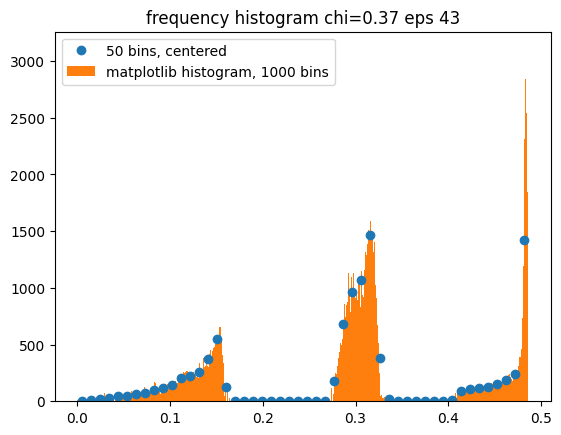

In [13]:
fig,ax = plt.subplots()
n_bins=1000
ax.plot(centers,hist/20.,'o',label='50 bins, centered')
ax.hist(band_sampling['all_bands'].flatten(), bins=n_bins,label='matplotlib histogram, 1000 bins')
ax.set_title('frequency histogram chi=0.'+names+f' eps {eps_names[0]}')
ax.legend()
plt.show()

**Calculating all histograms.**

Notice that we consider the center of each bin as stored in `centers`

chi= 0.37 Nsamples= 8
chi= 0.37 Nsamples= 8
chi= 0.37 Nsamples= 8


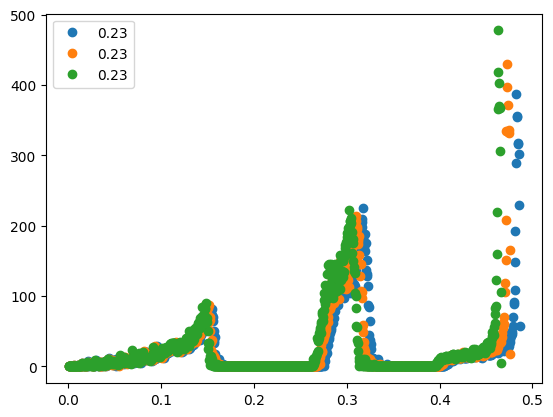

In [14]:
n_bins=1000

fig,ax = plt.subplots()

for eps in eps_names:
    file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{37}_band_sampling.h5"
    band_sampling=IO.read_dict_hdf5(file_name)
    print('chi=',0.37,'Nsamples=',band_sampling['Nsamples'])
    hist,edges=np.histogram(band_sampling['all_bands'],bins=n_bins)
    hist=hist/band_sampling['Nsamples']
    centers=(edges[:-1]+edges[1:])/2.
    ax.plot(centers,hist,'o',label=0.23)
    
ax.legend()
plt.show()    

**linear regression for the first few points of the histogram**.

This is to normalize the frequency histograms to present nDOS.

eps= 43 Nsamples= 8
eps= 45 Nsamples= 8
eps= 47 Nsamples= 8


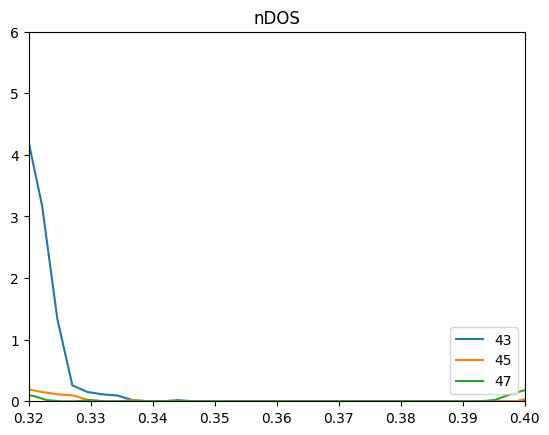

In [40]:

n_bins=200
first_terms=20 #points to calculate linear DOS
coefficients={} #to store coefficients
all_nDOS={} #to store the nDOS
all_centers={} #to store the exact center of the histogram

fig,ax = plt.subplots()
for eps in eps_names:
    file_name = rf"../Luis Data/Cavity_Like_Structures_h5/eps_{eps}_bands/chi_0.{37}_band_sampling.h5"
    band_sampling=IO.read_dict_hdf5(file_name)
    print('eps=',eps,'Nsamples=',band_sampling['Nsamples'])
    hist,edges=np.histogram(band_sampling['all_bands'],bins=n_bins)
    hist=hist/band_sampling['Nsamples']
    centers=(edges[:-1]+edges[1:])/2.
    #here to take first_terms points to normalize the histograms
    coef=np.polyfit(centers[:first_terms],hist[:first_terms],deg=1)
    hist=hist/(centers*coef[0]+coef[1])   
    #storing coefficients in the dictionary coefficients
    coefficients[eps]=coef
    all_nDOS[eps]=hist
    all_centers[eps]=centers
    #plotting results
    ax.plot(all_centers[eps],all_nDOS[eps],label=eps)

    
ax.legend(loc='lower right')
ax.set_title('nDOS')
#ax.set_yscale('log')
ax.set_xlim([0.32,0.4])
ax.set_ylim([0.,6.])
plt.show() 

In [41]:
for eps in eps_names:    
    print(eps,'coef=',coefficients[eps])
    

43 coef= [606.65257627  -1.2643797 ]
45 coef= [624.29996748  -1.37871241]
47 coef= [641.66351169  -1.47490602]


**To be more precise, we go by hand with the histograms to calculate PBG and lod nDOS margins**

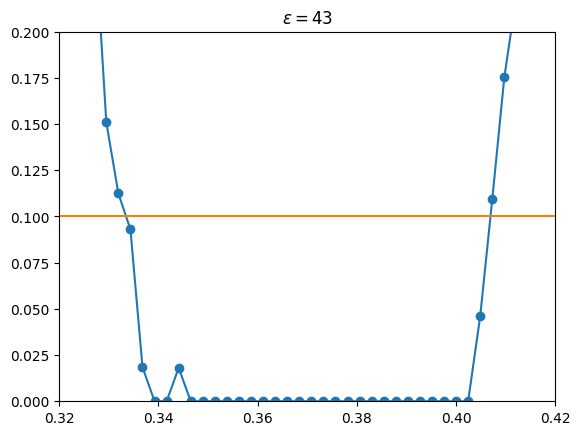

In [47]:
n=0
eps=eps_names[n]

fig,ax = plt.subplots()
ax.plot(all_centers[eps],all_nDOS[eps],'-o',label=eps)
ax.plot([0.2,0.5],[0.1,0.1])
ax.set_xlim([0.32,0.42])
ax.set_ylim([0.,0.2])
ax.set_title(r'$\epsilon=$'+eps)
plt.show()